# Ablation study (GEDI loss terms)

This notebook studies ablations on the **GEDI loss terms** (not the old feature-richness variants):
- Full GEDI
- No L_GEN
- No L_INV
- No L_PRIOR

The goal is to align with the paper-style ablation analysis on synthetic datasets.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.model import run_ablation_study
from src.utils import generate_synthetic_dataset, set_random_seed

set_random_seed(42)
sns.set_theme(style='whitegrid')

## 1. Setup: generate moons + circles (two noise settings)
We run ablation on two setups:
- `data_noise=0.03`: paper-like setting for direct comparison with Table 2.
- `data_noise=0.10`: harder custom setting for extended analysis.

All ablation training uses **X_train, y_train** for consistency with the training protocol.

In [2]:
# This cell supersedes the earlier single-noise setup.
# ablation_df now contains results for both noise=0.03 and noise=0.10.
noise_settings = [0.03, 0.10]
dataset_names = ['moons', 'circles']

ablation_tables = []
for data_noise in noise_settings:
    datasets = {}
    for dataset_name in dataset_names:
        X_train, X_test, y_train, y_test = generate_synthetic_dataset(
            dataset_name, data_noise=data_noise, random_state=42
        )
        datasets[dataset_name] = {
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test,
        }
        print(
            f"noise={data_noise:.2f} | {dataset_name}: "
            f"train={X_train.shape}, test={X_test.shape}"
        )

    for dataset_name in dataset_names:
        X_train = datasets[dataset_name]['X_train']
        y_train = datasets[dataset_name]['y_train']
        table = run_ablation_study(
            X_train,
            y_train,
            dataset_name=dataset_name,
            random_state=42,
        ).copy()
        table['Data noise'] = data_noise
        table['Setting'] = 'paper-like (0.03)' if np.isclose(data_noise, 0.03) else 'harder (0.10)'
        ablation_tables.append(table)

ablation_df = pd.concat(ablation_tables, ignore_index=True)
ablation_df

noise=0.03 | moons: train=(1400, 2), test=(600, 2)
noise=0.03 | circles: train=(1400, 2), test=(600, 2)
noise=0.10 | moons: train=(1400, 2), test=(600, 2)
noise=0.10 | circles: train=(1400, 2), test=(600, 2)


,Dataset,Variant,ACC,NMI,ARI,Silhouette,DBI,CHI,Data noise,Setting
0,moons,No L_GEN,0.842143,0.370843,0.467867,0.492912,0.821552,1917.193866,0.03,paper-like (0.03)
1,moons,Full GEDI,0.500000,0.000000,0.000000,NaN,NaN,NaN,0.03,paper-like (0.03)
2,moons,No L_INV,0.500000,0.000000,0.000000,NaN,NaN,NaN,0.03,paper-like (0.03)
3,moons,No L_PRIOR,0.500000,0.000000,0.000000,NaN,NaN,NaN,0.03,paper-like (0.03)
4,circles,No L_GEN,0.735714,0.323316,0.221844,0.272501,1.503150,410.963397,0.03,paper-like (0.03)
5,circles,Full GEDI,0.500000,0.000000,0.000000,NaN,NaN,NaN,0.03,paper-like (0.03)
6,circles,No L_INV,0.500000,0.000000,0.000000,NaN,NaN,NaN,0.03,paper-like (0.03)
7,circles,No L_PRIOR,0.500000,0.000000,0.000000,NaN,NaN,NaN,0.03,paper-like (0.03)
8,moons,No L_GEN,0.853571,0.399951,0.499694,0.485263,0.826312,1848.723562,0.10,harder (0.10)
9,moons,Full GEDI,0.500000,0.000000,0.000000,NaN,NaN,NaN,0.10,harder (0.10)


## 3. Comparison Table with Paper Table 2
The first table directly compares with Table 2 of the paper on the `data_noise=0.03` (paper-like) setting.
The second table is a custom-designed ablation on the harder setting `data_noise=0.10`.

In [3]:
# 3. Paper-style ablation comparison table (NMI)
variant_name_map = {
    'Full GEDI': 'GEDI',
    'No L_GEN': 'GEDI no gen',
    'No L_INV': 'GEDI no inv',
    'No L_PRIOR': 'GEDI no prior',
}

# A) Paper-like setting (noise=0.03) for direct comparison with paper Table 2
paper_like_df = ablation_df[np.isclose(ablation_df['Data noise'], 0.03)].copy()
paper_like_df['Variant'] = paper_like_df['Variant'].map(variant_name_map)

ours_rows = []
for dataset_name in ['moons', 'circles']:
    ds = paper_like_df[paper_like_df['Dataset'] == dataset_name]
    for _, row in ds.iterrows():
        ours_rows.append({
            'Dataset': dataset_name,
            'Variant': row['Variant'],
            'Our NMI': float(row['NMI']),
        })
ours_table = pd.DataFrame(ours_rows)

paper_table2_reference = pd.DataFrame([
    {'Dataset': 'moons',   'Variant': 'GEDI',          'Paper NMI': 0.94, 'Paper NMI std': 0.07},
    {'Dataset': 'moons',   'Variant': 'GEDI no gen',   'Paper NMI': 0.98, 'Paper NMI std': 0.00},
    {'Dataset': 'moons',   'Variant': 'GEDI no inv',   'Paper NMI': 0.11, 'Paper NMI std': 0.15},
    {'Dataset': 'moons',   'Variant': 'GEDI no prior', 'Paper NMI': 0.00, 'Paper NMI std': 0.00},
    {'Dataset': 'circles', 'Variant': 'GEDI',          'Paper NMI': 1.00, 'Paper NMI std': 0.01},
    {'Dataset': 'circles', 'Variant': 'GEDI no gen',   'Paper NMI': 0.83, 'Paper NMI std': 0.12},
    {'Dataset': 'circles', 'Variant': 'GEDI no inv',   'Paper NMI': 0.22, 'Paper NMI std': 0.13},
    {'Dataset': 'circles', 'Variant': 'GEDI no prior', 'Paper NMI': 0.00, 'Paper NMI std': 0.00},
])

comparison_table2_paperlike = paper_table2_reference.merge(
    ours_table, on=['Dataset', 'Variant'], how='left'
)
comparison_table2_paperlike['Abs diff vs paper'] = (
    comparison_table2_paperlike['Our NMI'] - comparison_table2_paperlike['Paper NMI']
).abs()
comparison_table2_paperlike['Rel diff %'] = (
    comparison_table2_paperlike['Abs diff vs paper']
    / comparison_table2_paperlike['Paper NMI'].replace(0, np.nan)
    * 100
).round(1)
comparison_table2_paperlike = comparison_table2_paperlike.sort_values(
    ['Dataset', 'Variant']
).reset_index(drop=True)

print('Comparison with paper Table 2 (noise=0.03):')
display(comparison_table2_paperlike)

# B) Harder custom setting (noise=0.10)
harder_df = ablation_df[np.isclose(ablation_df['Data noise'], 0.10)].copy()
harder_df['Variant'] = harder_df['Variant'].map(variant_name_map)
harder_table = harder_df[['Dataset', 'Variant', 'NMI']].rename(columns={'NMI': 'Our NMI (noise=0.10)'})
harder_table = harder_table.sort_values(['Dataset', 'Variant']).reset_index(drop=True)

print('Custom harder ablation setting (noise=0.10):')
display(harder_table)

Comparison with paper Table 2 (noise=0.03):


,Dataset,Variant,Paper NMI,Paper NMI std,Our NMI,Abs diff vs paper,Rel diff %
0,circles,GEDI,1.00,0.01,0.000000,1.000000,100.0
1,circles,GEDI no gen,0.83,0.12,0.323316,0.506684,61.0
2,circles,GEDI no inv,0.22,0.13,0.000000,0.220000,100.0
3,circles,GEDI no prior,0.00,0.00,0.000000,0.000000,NaN
4,moons,GEDI,0.94,0.07,0.000000,0.940000,100.0
5,moons,GEDI no gen,0.98,0.00,0.370843,0.609157,62.2
6,moons,GEDI no inv,0.11,0.15,0.000000,0.110000,100.0
7,moons,GEDI no prior,0.00,0.00,0.000000,0.000000,NaN


Custom harder ablation setting (noise=0.10):


,Dataset,Variant,Our NMI (noise=0.10)
0,circles,GEDI,0.000000
1,circles,GEDI no gen,0.001035
2,circles,GEDI no inv,0.000000
3,circles,GEDI no prior,0.000000
4,moons,GEDI,0.000000
5,moons,GEDI no gen,0.399951
6,moons,GEDI no inv,0.000000
7,moons,GEDI no prior,0.000000


## 4. Visualization
NMI bar charts per variant provide a quick view of which ablation hurts performance the most on each dataset.

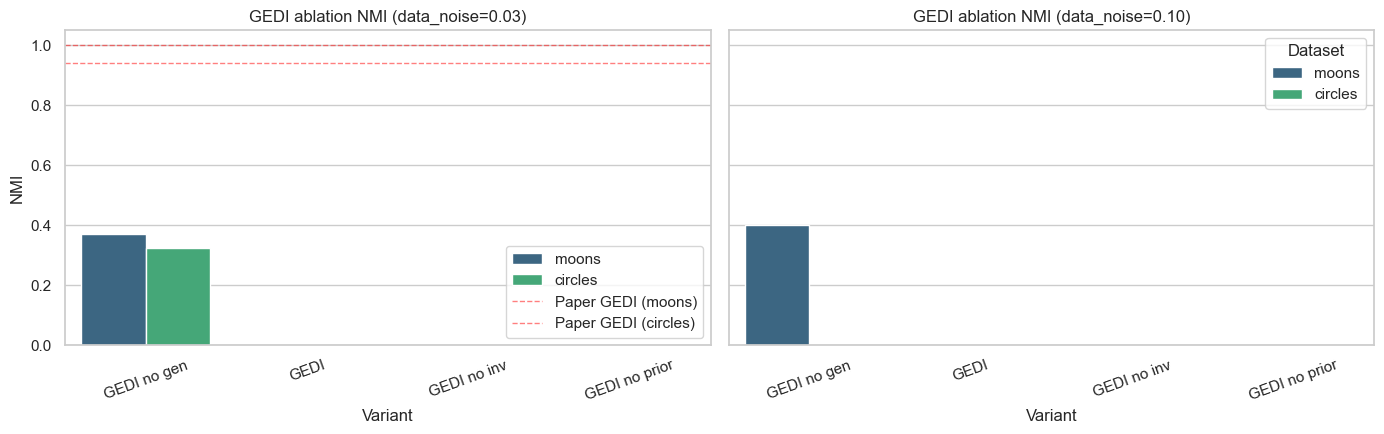

In [4]:
plot_df = ablation_df.copy()
plot_df['Variant'] = plot_df['Variant'].map({
    'Full GEDI': 'GEDI',
    'No L_GEN': 'GEDI no gen',
    'No L_INV': 'GEDI no inv',
    'No L_PRIOR': 'GEDI no prior',
})

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, data_noise in zip(axes, [0.03, 0.10]):
    sub = plot_df[np.isclose(plot_df['Data noise'], data_noise)]
    sns.barplot(
        data=sub,
        x='Variant',
        y='NMI',
        hue='Dataset',
        palette='viridis',
        ax=ax,
    )
    ax.set_title(f'GEDI ablation NMI (data_noise={data_noise:.2f})')
    ax.tick_params(axis='x', rotation=20)

    if np.isclose(data_noise, 0.03):
        paper_gedi_nmi = {'moons': 0.94, 'circles': 1.00}
        for dataset, val in paper_gedi_nmi.items():
            ax.axhline(
                y=val,
                color='red',
                linestyle='--',
                alpha=0.5,
                linewidth=1,
                label=f'Paper GEDI ({dataset})',
            )

handles, labels = axes[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))
axes[0].legend(unique.values(), unique.keys(), loc='best')

plt.tight_layout()
plt.show()

## 5. Discussion
- Compare the NMI drop across `No L_GEN`, `No L_INV`, `No L_PRIOR` to identify the most critical component.
- Check whether the ranking of variants is consistent between moons and circles.
- Results for `data_noise=0.03` are for direct comparison with the paper; `data_noise=0.10` is a custom ablation on a harder setting.
- The notebook currently uses **1 seed** (`random_state=42`) for ablation to keep runtime short. For more stable results, consider running 3–5 seeds and reporting mean/std per variant.